In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import save
import scipy
from scipy import stats
# import cv2
from pathlib import Path
import seaborn as sns
from matplotlib import cm
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as plticker
from scipy.stats import gaussian_kde
from matplotlib.colors import TwoSlopeNorm
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors
import matplotlib.collections as mcoll
import os
from scipy.interpolate import UnivariateSpline

In [64]:
## look at individual stimui responses 

def load_dataframes_from_subfolders(parent_path):
    dataframes = []
    for subfolder in parent_path.iterdir():
        if subfolder.is_dir():
            for file_path in subfolder.glob("*.csv"):
                dataframes.append(pd.read_csv(file_path))
    return dataframes

# Define the parent directory
parent_dir = Path(r"/Volumes/LaCie/free_swimming/7dpf_TRex/adenosine_2.5mM")
exp_name = parent_dir.name
color = 'plum'
stim = 'Ade'

# Load dataframes from "stim" and "control" subfolders
stim_fish = load_dataframes_from_subfolders(parent_dir / "stim")
control_fish = load_dataframes_from_subfolders(parent_dir / "base")

## filter the data for average analysis 

In [65]:
# remove fish not tracked for the majority of the video and fish that don't swim much 
def total_distance_travelled(df):
    dx = df['x'][df['mask']].diff()
    dy = df['y'][df['mask']].diff()
    return np.sqrt(dx**2 + dy**2).sum()

def is_fish_significantly_moving(df, movement_threshold, tracking_threshold):
    total_frames = len(df)
    tracked_frames = len(df[df["mask"]])
    vx = df['acceleration'][df['mask']]
    
    tracking_percentage = (tracked_frames / total_frames) * 100

    if tracking_percentage < tracking_threshold:
        return False
    
    # elif np.any(vx > jump_threshold):
    #     return False
    
    valid_data = df[df["mask"]]
    return total_distance_travelled(valid_data) > movement_threshold
    
movement_threshold = 60
tracking_threshold = 90
# jump_threshold = 500

filtered_stim = [fish_df for fish_df in stim_fish if is_fish_significantly_moving(fish_df, movement_threshold, tracking_threshold)]
filtered_control = [fish_df for fish_df in control_fish if is_fish_significantly_moving(fish_df, movement_threshold, tracking_threshold)]                        


In [66]:
len(stim_fish),len(filtered_stim), len(control_fish), len(filtered_control)

(164, 146, 163, 125)

## Create subtracted heatmaps

In [58]:
def get_all_x_y(list_dfs):
    """
    Extracts the second half of x and y coordinates from a list of dataframes
    where the mask condition is True.

    :param list_dfs: List of pandas DataFrames with columns 'x', 'y', and 'mask'.
    :return: Two lists containing all x and y coordinates.
    """
    all_x = []
    all_y = []

    for df in list_dfs:
        half_len = len(df) // 2
        filtered_df = df[half_len:]
        all_x.extend(filtered_df.loc[filtered_df['mask'], 'x'])
        all_y.extend(filtered_df.loc[filtered_df['mask'], 'y'])
    
    return all_x, all_y

def normalize_to_range(values, new_min=-1, new_max=1):
    """
    Normalize a list of values to a specified range.

    :param values: List of numbers to be normalized.
    :param new_min: Minimum value of the new range.
    :param new_max: Maximum value of the new range.
    :return: List of normalized numbers.
    """
    old_min = min(values)
    old_max = max(values)

    # Min-max normalization to 0-1 range
    normalized_0_1 = [(x - old_min) / (old_max - old_min) for x in values]

    # Scale to new range (new_min to new_max)
    normalized = [new_min + (x * (new_max - new_min)) for x in normalized_0_1]

    return normalized

def normalize_heatmap(heatmap):
    """
    Normalize a heatmap so that the sum of all density values equals 1.

    :param heatmap: 2D numpy array representing the heatmap.
    :return: Normalized heatmap.
    """
    return heatmap / np.sum(heatmap)

def create_difference_heatmap(title, stim_df_list, control_df_list, arena_size=(2, 1), bins=(11, 6), sigma=1):
    """
    Create a difference heatmap between stimulus and control conditions from a list of dataframes,
    with optional Gaussian smoothing.

    :param title: Title of the plot.
    :param stim_df_list: List of dataframes for the stimulus condition.
    :param control_df_list: List of dataframes for the control condition.
    :param arena_size: Size of the arena (width, height) in normalized units.
    :param bins: Number of bins for the heatmap in each dimension (x_bins, y_bins).
    :param sigma: Standard deviation for Gaussian smoothing.
    """
    # Step 1: Calculate heatmap for stimulus condition
    stim_x_positions, stim_y_positions = get_all_x_y(stim_df_list)
    stim_normalised_x = normalize_to_range(stim_x_positions, new_min=0, new_max=arena_size[0])
    stim_normalised_y = normalize_to_range(stim_y_positions, new_min=0, new_max=arena_size[1])
    
    stim_heatmap, xedges, yedges = np.histogram2d(stim_normalised_x, stim_normalised_y, bins=bins, range=[[0, arena_size[0]], [0, arena_size[1]]])
    
    # Apply Gaussian smoothing to the stimulus heatmap
    stim_heatmap = gaussian_filter(normalize_heatmap(stim_heatmap), sigma=sigma)

    # Step 2: Calculate heatmap for control condition
    control_x_positions, control_y_positions = get_all_x_y(control_df_list)
    control_normalised_x = normalize_to_range(control_x_positions, new_min=0, new_max=arena_size[0])
    control_normalised_y = normalize_to_range(control_y_positions, new_min=0, new_max=arena_size[1])
    
    control_heatmap, _, _ = np.histogram2d(control_normalised_x, control_normalised_y, bins=bins, range=[[0, arena_size[0]], [0, arena_size[1]]])
    
    # Apply Gaussian smoothing to the control heatmap
    control_heatmap = gaussian_filter(normalize_heatmap(control_heatmap), sigma=sigma)

    # Step 3: Calculate the difference heatmap (stimulus - control)
    difference_heatmap = stim_heatmap - control_heatmap

    # Step 4: Plot the difference heatmap
    fig = plt.figure(figsize=(6, 3))
    ax_main = fig.add_subplot(111)
    ax_main.set_title(title, fontsize=22, weight='bold', x=0.1, y=1.15)  # Set title on the main axis
    
    # Define the colormap normalization
    norm = TwoSlopeNorm(vmin=-0.02, vcenter=0, vmax=0.02)
    # Plotting the main heatmap
    cax = ax_main.imshow(difference_heatmap.T, extent=[0, arena_size[0], 0, arena_size[1]], 
                         origin='lower', aspect='auto', cmap='coolwarm', norm=norm, interpolation='nearest')
    ax_main.set_xlabel(r"$X_{\mathrm{norm}}$", fontsize=26)
    ax_main.set_ylabel(r"$Y_{\mathrm{norm}}$", fontsize=26)
    ax_main.tick_params(axis='both', labelsize=26)
    # ax_main.axvline(x=1, color='black', linestyle='dashed', alpha=0.5)

    # Step 5: Calculate and plot the difference histograms
    stim_x_hist, _ = np.histogram(stim_normalised_x, bins=xedges, range=[0, arena_size[0]])
    control_x_hist, _ = np.histogram(control_normalised_x, bins=xedges, range=[0, arena_size[0]])
    diff_x_hist = stim_x_hist - control_x_hist

    stim_y_hist, _ = np.histogram(stim_normalised_y, bins=yedges, range=[0, arena_size[1]])
    control_y_hist, _ = np.histogram(control_normalised_y, bins=yedges, range=[0, arena_size[1]])
    diff_y_hist = stim_y_hist - control_y_hist
    
    # Set bar heights to match the heatmap grid
    bbox = ax_main.get_position()
    ax_x_hist = fig.add_axes([bbox.x0, bbox.y1 + 0.01, bbox.width, 0.09])  # Adjust y1 and height as needed for x-histogram
    ax_y_hist = fig.add_axes([bbox.x1 + 0.01, bbox.y0, 0.06, bbox.height])  # Adjust x1 and width as needed for y-histogram
    
    ax_x_hist.margins(x=0)
    ax_y_hist.margins(y=0)
    
    ax_x_hist.axis('off')
    ax_y_hist.axis('off')
    
    # Marginal histograms representing the difference
    ax_x_hist.bar(range(len(diff_x_hist)), diff_x_hist,  width=1, color='darkblue', alpha=0.6)
    ax_y_hist.barh(range(len(diff_y_hist)), diff_y_hist, height=1, color='darkblue', alpha=0.6)

    # Add color bar
    ax_colorbar = fig.add_axes([bbox.x1 + 0.1, bbox.y0, 0.02, bbox.height])
    colorbar = plt.colorbar(cax, cax=ax_colorbar)
    colorbar.ax.tick_params(labelsize=26)
    colorbar.set_label(r"Δ Density", fontsize=26, labelpad=10)
    colorbar.set_ticks([-0.02, 0, 0.02])  # Optional: set ticks explicitly

    
    # plt.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/4-7dpf_new_{title}_heatmap.svg", format="svg", dpi=300, bbox_inches="tight")
    plt.show()


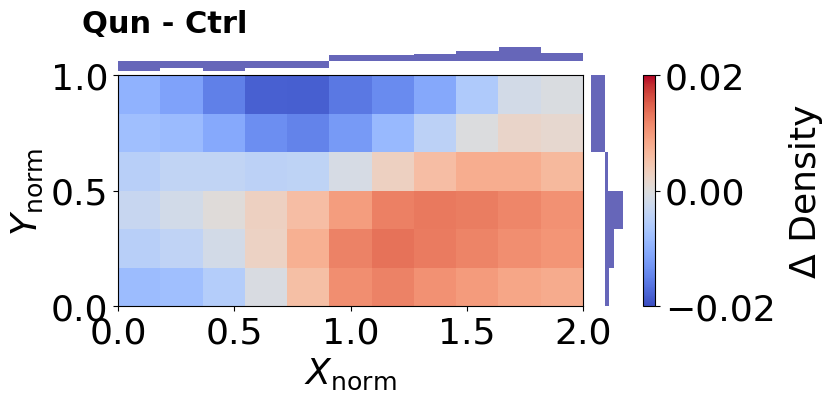

In [57]:
create_difference_heatmap('Qun - Ctrl', filtered_stim, filtered_control)

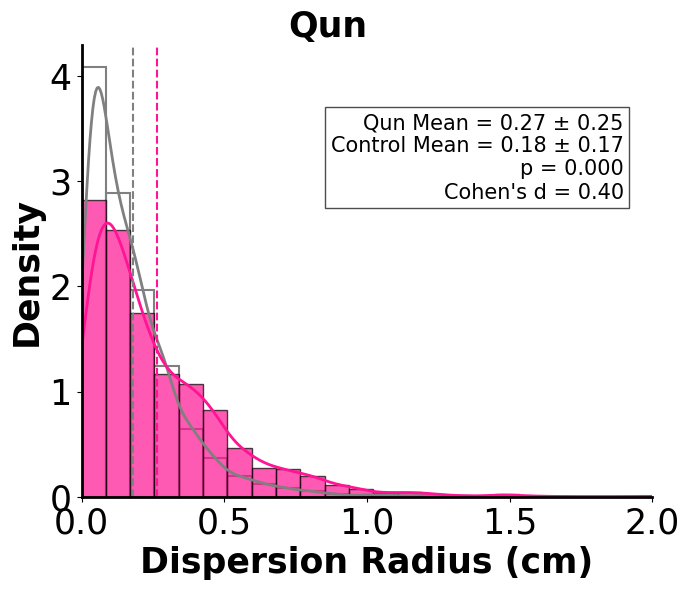

In [580]:
def plot_combined_histogram(stim_data, control_data, p_value, cohen_d, 
                            mean_stim, std_stim, mean_control, std_control,
                            color=color):  # Add color as argument if needed
    """Plots density-based histogram and KDE for both stimulus and control groups."""
    plt.figure(figsize=(7, 6))

    # Combine for consistent binning
    all_radii = pd.concat([stim_data["radius"], control_data["radius"]])
    bins = np.linspace(all_radii.min(), all_radii.max(), 30)
    
    # Histogram: Control
    plt.hist(control_data["radius"], bins=bins, alpha=1.0, facecolor='none',
         edgecolor='grey', linewidth=1.5, label="Control (Histogram)", density=True)

    # Histogram: Stimulus
    plt.hist(stim_data["radius"], bins=bins, alpha=0.7, color=color,
             edgecolor='black', label="Stimulus (Histogram)", density=True)

    # KDE lines
    x_vals = np.linspace(all_radii.min(), all_radii.max(), 500)
    control_kde = gaussian_kde(control_data["radius"])
    stim_kde = gaussian_kde(stim_data["radius"])

    plt.plot(x_vals, control_kde(x_vals), color='grey', linestyle='-', linewidth=2, label="Control (KDE)")
    plt.plot(x_vals, stim_kde(x_vals), color=color, linestyle='-', linewidth=2, label="Stimulus (KDE)")

    # Mean lines
    plt.axvline(mean_control, color='grey', linestyle='dashed', linewidth=1.5, label="Control Mean")
    plt.axvline(mean_stim, color=color, linestyle='dashed', linewidth=1.5, label="Stimulus Mean")

    # Annotate stats
    stats_text = (
    f"{stim} Mean = {mean_stim:.2f} ± {std_stim:.2f}\n"
    f"Control Mean = {mean_control:.2f} ± {std_control:.2f}\n"
    f"p = {p_value:.3f}\n"
    f"Cohen's d = {cohen_d:.2f}"
    )
    plt.text(0.95, 0.85, stats_text, transform=plt.gca().transAxes, fontsize=15,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))

    # Labels and title
    
    ax = plt.gca()
    ax.tick_params(axis='both', labelsize=25)
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    sns.despine(ax=ax, left=False, bottom=False)  # Keep bottom axis
    
    plt.xlabel('Dispersion Radius (cm)', fontsize=25, weight='bold')
    plt.ylabel('Density', fontsize=25, weight='bold')
    plt.title(f'{stim}', ha='right', fontsize=25, weight='bold')
    plt.xlim(0,2)
    plt.tight_layout()
    # plt.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_{stim}_dispersion_histogram.svg", format="svg", dpi=300, bbox_inches="tight")
    plt.show()
    

# Plot combined histogram with std lines
plot_combined_histogram(stim_df, control_df, p_value, cohen_d, mean_stim, std_stim, mean_control, std_control)

In [581]:
result_df = summarize_metric_df(
    stim_df['radius'],
    control_df['radius'],
    group1_label='Stim dispersion',
    group2_label='Ctrl dispersion',
    metric_name='Min. enclosing circle (cm)',
    stim=stim,
    test='mannwhitneyu'
)

result_df

,stim,metric,group1,n1,group2,n2,mean1,std1,mean2,std2,test,pvalue,cohen_d,rank_biserial_r
0,Qun,Min. enclosing circle (cm),Stim dispersion,2837,Ctrl dispersion,4018,0.265727,0.249804,0.180185,0.170397,mannwhitneyu,1.043017e-47,0.413269,-0.205455


In [582]:
def compute_minimum_enclosing_circle(points):
    """Computes the minimum enclosing circle given a set of 2D points."""
    if len(points) < 2:
        return 0  # No meaningful circle if only one point
    points = np.array(points, dtype=np.float32)
    (x, y), radius = cv2.minEnclosingCircle(points)
    return radius

def smooth_positions(df, time_column='time', x_column='x', y_column='y', smoothing_factor=0.5):
    """Smooth x and y positions using cubic spline interpolation."""
    times = df[time_column].values
    x_vals = df[x_column].values
    y_vals = df[y_column].values

    # Fit cubic splines
    spline_x = UnivariateSpline(times, x_vals, s=smoothing_factor * len(times))
    spline_y = UnivariateSpline(times, y_vals, s=smoothing_factor * len(times))

    # Replace with smoothed values
    df[x_column] = spline_x(times)
    df[y_column] = spline_y(times)

    return df

def analyze_dispersal_with_shift(fish_data, time_column='time', x_column='x', y_column='y', mask_column='mask',
                                 speed_column='speed', start_time=600, bin_size=3, arena_width=14, 
                                 odor_zone_depth=1, smoothing_factor=0.5, speed_threshold=3):
    """
    Computes dispersal (radius) and center shift across bins within odor zone.
    """
    assert 1 <= odor_zone_depth <= 3, "odor_zone_depth must be 1, 2, or 3"

    section_width = arena_width / 6
    x_max = section_width * odor_zone_depth

    combined_dispersal_df = pd.DataFrame()
    combined_shift_df = pd.DataFrame()

    for i, df in enumerate(fish_data):
        df = df[(df[time_column] >= start_time) & 
                (df[mask_column]) & 
                (df[speed_column] < speed_threshold)].copy()

        if len(df) < 5:
            continue

        df = smooth_positions(df, time_column=time_column, x_column=x_column, y_column=y_column,
                              smoothing_factor=smoothing_factor)
        df = df[df[x_column] <= x_max].copy()
        df['time_bin'] = (df[time_column] // bin_size).astype(int) * bin_size

        bin_centers = []
        bin_radii = []
        unique_times = sorted(df['time_bin'].unique())

        for t in unique_times:
            subset = df[df['time_bin'] == t][[x_column, y_column]].dropna()
            if len(subset) > 0:
                points = subset.values.astype(np.float32)
                (cx, cy), radius = cv2.minEnclosingCircle(points)
                bin_radii.append((t, radius))
                bin_centers.append((t, cx, cy))

        # Store radius info
        fish_dispersal_df = pd.DataFrame(bin_radii, columns=['time_bin', 'radius'])
        fish_dispersal_df['fish_id'] = i
        combined_dispersal_df = pd.concat([combined_dispersal_df, fish_dispersal_df], ignore_index=True)

        # Compute center shifts between successive bins
        shifts = []
        for (t1, x1, y1), (t2, x2, y2) in zip(bin_centers[:-1], bin_centers[1:]):
            shift = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            shifts.append((t2, shift))  # align shift with second bin
        if shifts:
            fish_shift_df = pd.DataFrame(shifts, columns=['time_bin', 'center_shift'])
            fish_shift_df['fish_id'] = i
            combined_shift_df = pd.concat([combined_shift_df, fish_shift_df], ignore_index=True)

    return combined_dispersal_df, combined_shift_df

def perform_statistical_test(stim_data, control_data):
    """Performs a Mann-Whitney U test to compare dispersal distributions and calculates effect size."""
    stim_values = stim_data["radius"].values
    control_values = control_data["radius"].values

    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(stim_values, control_values, alternative='two-sided')

    # Mean and standard deviation
    mean_stim, std_stim = mean(stim_values), stdev(stim_values)
    mean_control, std_control = mean(control_values), stdev(control_values)

    # Cohen's d effect size
    pooled_std = np.sqrt((std_stim**2 + std_control**2) / 2)
    cohen_d = (mean_stim - mean_control) / pooled_std

    print(f"Mann-Whitney U Test: U={stat}, p={p_value:.5f}")
    print(f"Stimulus Group: Mean = {mean_stim:.3f}, Std = {std_stim:.3f}")
    print(f"Control Group: Mean = {mean_control:.3f}, Std = {std_control:.3f}")
    print(f"Effect Size (Cohen's d): {cohen_d:.3f}")

    return p_value, cohen_d, mean_stim, std_stim, mean_control, std_control


    
# Example usage
stim_dispersal, stim_shift = analyze_dispersal_with_shift(
    filtered_stim, start_time=300, arena_width=14, odor_zone_depth=3,
    smoothing_factor=0.3, speed_threshold=3)

control_dispersal, control_shift = analyze_dispersal_with_shift(
    filtered_control, start_time=300, arena_width=14, odor_zone_depth=3,
    smoothing_factor=0.3, speed_threshold=3)

# Perform statistical test
p_value, cohen_d, mean_stim, std_stim, mean_control, std_control = perform_statistical_test(stim_df, control_df)

Mann-Whitney U Test: U=6870528.5, p=0.00000
Stimulus Group: Mean = 0.266, Std = 0.250
Control Group: Mean = 0.180, Std = 0.170
Effect Size (Cohen's d): 0.400


In [583]:
def plot_center_shift_timecourse(stim_shift_df, control_shift_df, bin_size=3):
    plt.figure(figsize=(10, 5))

    # Average shift per time_bin
    stim_avg = stim_shift_df.groupby('time_bin')['center_shift'].mean()
    control_avg = control_shift_df.groupby('time_bin')['center_shift'].mean()

    plt.plot(stim_avg.index, stim_avg.values, label='Stimulus', color=color)
    plt.plot(control_avg.index, control_avg.values, label='Control', color='gray')

    plt.xlabel(f'Time (s, binned every {bin_size}s)')
    plt.ylabel('Avg. Center Shift (cm)')
    plt.title('Time-Resolved Shift in Center of Movement')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    
def plot_avg_center_shift_per_fish(stim_shift_df, control_shift_df):
    # Average shift per fish
    stim_avg = stim_shift_df.groupby('fish_id')['center_shift'].mean().reset_index()
    control_avg = control_shift_df.groupby('fish_id')['center_shift'].mean().reset_index()

    stim_avg['group'] = f'{stim}'
    control_avg['group'] = 'Control'
    all_avg = pd.concat([stim_avg, control_avg])

    plt.figure(figsize=(7, 5))
    sns.boxplot(x='group', y='center_shift', data=all_avg, palette=[color, 'gray'])
    sns.stripplot(x='group', y='center_shift', data=all_avg, color='black', alpha=0.6, jitter=True)

    # Mann-Whitney test
    stat, p = mannwhitneyu(stim_avg['center_shift'], control_avg['center_shift'])
    ax=plt.gca()
    ax.tick_params(axis='both', labelsize=25)
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    sns.despine(ax=ax, left=False, bottom=False)  # Keep bottom axis
    
    plt.title(f'p = {p:.3f}', fontsize=20)
    plt.ylabel('Mean Center Shift (cm)', fontsize=25, weight='bold')
    plt.xlabel('')
    plt.xticks(fontweight='bold')
    plt.tight_layout()
    # plt.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_{stim}_mean_center_shift.svg", format="svg", dpi=300, bbox_inches="tight")
    plt.show()
    
    return stim_avg['center_shift'], control_avg['center_shift']
    

In [584]:
def plot_avg_center_shift_per_fish_violin(stim_shift_df, control_shift_df):
    # Average shift per fish
    stim_avg = stim_shift_df.groupby('fish_id')['center_shift'].mean().reset_index()
    control_avg = control_shift_df.groupby('fish_id')['center_shift'].mean().reset_index()

    stim_avg_vals = stim_avg['center_shift'].values
    control_avg_vals = control_avg['center_shift'].values

    # Mann-Whitney test
    stat, p = mannwhitneyu(stim_avg_vals, control_avg_vals)

    # significance stars
    if p <= 0.001:
        significance = '***'
    elif p <= 0.01:
        significance = '**'
    elif p <= 0.05:
        significance = '*'
    else:
        significance = 'ns'

    # Outlier removal (optional, for plotting only)
    def remove_outliers_iqr(data):
        q1 = np.percentile(data, 25)
        q3 = np.percentile(data, 75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return data[(data >= lower) & (data <= upper)]

    plot_stim = remove_outliers_iqr(stim_avg_vals)
    plot_ctrl = remove_outliers_iqr(control_avg_vals)

    # Data & labels
    plot_data = [plot_ctrl, plot_stim]
    labels = ['Ctrl', stim]  # `stim` variable should already exist in your scope
    positions = [0, 1]
    colors = ['gray', color]   # `color` variable should already exist in your scope

    # Start figure
    fig, ax = plt.subplots(figsize=(6, 6))

    # Violin plot
    parts = ax.violinplot(plot_data, positions=positions, widths=0.8,
                          showmeans=False, showmedians=False, showextrema=False)

    # Color violins
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_edgecolor('black')
        pc.set_alpha(0.9)
        pc.set_linewidth(1.5)

    # Add median & quartile lines
    half_width = 0.75  # half of widths in violinplot
    for i, d in enumerate(plot_data):
        d = np.array(d)
        d = d[~np.isnan(d)]
        median = np.median(d)
        q1 = np.percentile(d, 25)
        q3 = np.percentile(d, 75)
        center = positions[i]

        ax.hlines(median, center - 0.3 * half_width, center + 0.3 * half_width,
                  color='black', linewidth=2.5)

        ax.hlines([q1, q3], center - 0.25 * half_width, center + 0.25 * half_width,
                  color='black', linestyle='--', linewidth=1.5)

    # Customize axes
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=16, fontweight='bold')
    ax.set_ylabel("Mean Center Shift (cm)", fontsize=26)
    ax.tick_params(axis='both', labelsize=16)

    # Significance text
    y_max = max([max(d) for d in plot_data]) * 1.1
    ax.text(np.mean(positions), y_max, significance, ha='center',
            fontsize=20, fontweight='bold')

    # Thicker axes
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    sns.despine(ax=ax, left=False, bottom=False)
    ax.tick_params(left=True, bottom=True, labelsize=26)
    plt.ylim(0,1.5)

    plt.tight_layout()
    plt.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_{stim}_mean_center_shift.svg", format="svg", dpi=300, bbox_inches="tight")
    plt.show()

    return stim_avg_vals, control_avg_vals

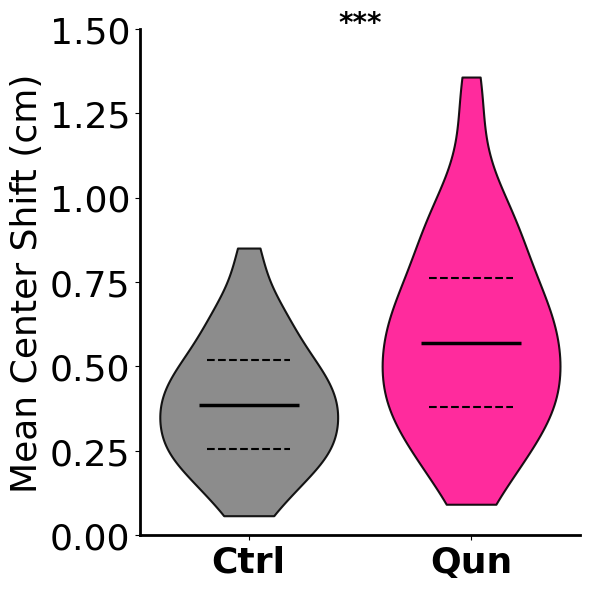

In [585]:
# plot_center_shift_timecourse(stim_shift, control_shift)
stim_avg, control_avg = plot_avg_center_shift_per_fish_violin(stim_shift, control_shift)

In [469]:
result_df = summarize_metric_df(
    stim_avg,
    control_avg,
    group1_label='Stim dispersion',
    group2_label='Ctrl dispersion',
    metric_name='Mean center shift (cm)',
    stim=stim,
    test='mannwhitneyu'
)

result_df

,stim,metric,group1,n1,group2,n2,mean1,std1,mean2,std2,test,pvalue,cohen_d,rank_biserial_r
0,Qun,Mean center shift (cm),Stim dispersion,77,Ctrl dispersion,65,0.618971,0.316339,0.437528,0.248555,mannwhitneyu,0.000232,0.631451,-0.359441


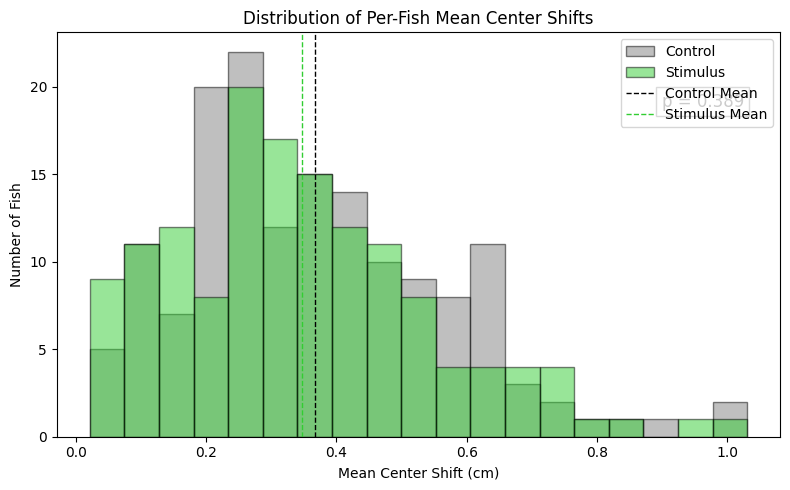

In [230]:
def plot_avg_center_shift_histogram(stim_shift_df, control_shift_df):
    # Compute per-fish averages
    stim_avg = stim_shift_df.groupby('fish_id')['center_shift'].mean().reset_index()
    control_avg = control_shift_df.groupby('fish_id')['center_shift'].mean().reset_index()

    stim_avg_values = stim_avg['center_shift'].values
    control_avg_values = control_avg['center_shift'].values

    # Histogram bins based on combined data
    all_values = np.concatenate([stim_avg_values, control_avg_values])
    bins = np.linspace(all_values.min(), all_values.max(), 20)

    plt.figure(figsize=(8, 5))

    # Plot histograms
    plt.hist(control_avg_values, bins=bins, alpha=0.5, color='gray', edgecolor='black', label='Control')
    plt.hist(stim_avg_values, bins=bins, alpha=0.5, color=color, edgecolor='black', label='Stimulus')

    # Compute means and stds
    mean_control = control_avg_values.mean()
    mean_stim = stim_avg_values.mean()
    std_control = control_avg_values.std()
    std_stim = stim_avg_values.std()

    # Vertical lines for means ± std
    plt.axvline(mean_control, color='black', linestyle='dashed', linewidth=1, label='Control Mean')
    plt.axvline(mean_stim, color=color, linestyle='dashed', linewidth=1, label='Stimulus Mean')

    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(stim_avg_values, control_avg_values)
    plt.text(0.95, 0.85, f'p = {p_value:.3f}', transform=plt.gca().transAxes,
             fontsize=12, verticalalignment='top', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))

    plt.xlabel('Mean Center Shift (cm)')
    plt.ylabel('Number of Fish')
    plt.title('Distribution of Per-Fish Mean Center Shifts')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
plot_avg_center_shift_histogram(stim_shift, control_shift)

In [ ]:
stim_mean_disp = stim_df['radius'].mean()
control_mean_disp = control_df['radius'].mean()

print(f"Average dispersal (Stimulus): {stim_mean_disp:.3f}")
print(f"Average dispersal (Control): {control_mean_disp:.3f}")

## look at distance travelled distribution 

In [ ]:
total_distance = []
for fish in stim_fish: 
    dist = total_distance_travelled(fish)
    total_distance.append(dist)

for fish in control_fish:
    dist_c = total_distance_travelled(fish)
    total_distance.append(dist_c)

plt.figure(figsize=(10, 6))
plt.hist(total_distance, bins=20)  # Adjust the number of bins as needed
# Get current x-axis limits
xmin, xmax = plt.xlim()
# Set x-axis ticks: for example, create 10 evenly spaced ticks from xmin to xmax
xticks = np.linspace(xmin, xmax, 20)
# Apply the new ticks


plt.xticks(xticks)
plt.title(exp_name)
plt.xlabel('distance travelled')
plt.show()

## plot Single fish examples

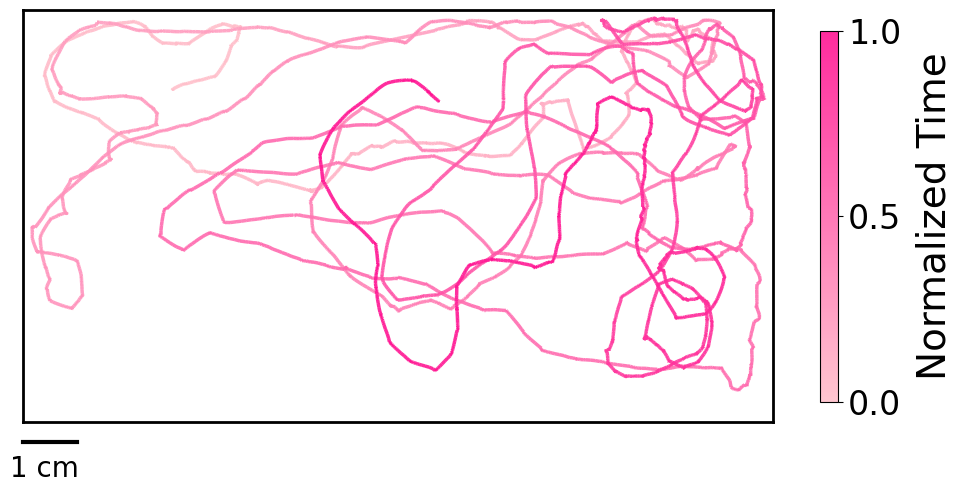

In [5]:
fish = filtered_stim[59]   ## quinine fish 59  food extract 57? 

# Ensure missing values are explicitly represented as NaN
fish['x'] = fish['x'].replace([np.inf, -np.inf], np.nan)
fish['y'] = fish['y'].replace([np.inf, -np.inf], np.nan)
fish['time'] = fish['time'].replace([np.inf, -np.inf], np.nan)

# Interpolate missing values in x, y, and time
fish['x'] = fish['x'].interpolate(method='linear', limit_direction='both')
fish['y'] = fish['y'].interpolate(method='linear', limit_direction='both')
fish['time'] = fish['time'].interpolate(method='linear', limit_direction='both')

# Normalize time values for proper color mapping
time_normalized = (fish['time'] - fish['time'].min()) / (fish['time'].max() - fish['time'].min())

# Define custom colormap from light pink to dark magenta
cmap = mcolors.LinearSegmentedColormap.from_list("pink_magenta", ["pink", "deeppink"])
# cmap = mcolors.LinearSegmentedColormap.from_list("green_lime", ["lightgreen", "darkgreen"])

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Prepare segments for colored line
points = np.array([fish['x'], fish['y']]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create a LineCollection for time-based color mapping with thicker lines
norm = plt.Normalize(time_normalized.min(), time_normalized.max())
lc = mcoll.LineCollection(segments, cmap=cmap, norm=norm, linewidth=2.5, alpha=0.9)  # Thicker line
lc.set_array(time_normalized)  # Set colors based on normalized time

# Add the colored trajectory line
ax.add_collection(lc)

# Overlay points for additional size
ax.scatter(fish['x'], fish['y'], c=time_normalized, cmap=cmap, s=1, alpha=0.8, edgecolors='none')  # Increase `s` for larger points

# Adjust plot limits
ax.set_xlim(0.1, 14)
ax.set_ylim(0.6, 6.8)
ax.set_yticks([])
ax.set_xticks([])

# Increase axis line width
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)

# Add scale bar (1 cm)
ax.text(0.5, -0.1, "1 cm", ha='center', va='center', fontsize=20, color='black')
ax.plot([0.1, 1.1], [0.3, 0.3], color='black', linewidth=3, clip_on=False)

# Add colorbar
cbar = plt.colorbar(lc, ax=ax, shrink=0.9)
cbar.set_label(r"Normalized Time", fontsize=28, labelpad=10)
cbar.ax.tick_params(labelsize=24)  # Increase colorbar number size
cbar.set_ticks([0, 0.5, 1.0]) 

# Show plot
plt.tight_layout()
# plt.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/svg_figures/7dpf_trajectory_qui_example.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()